## Обучение с учителем. Задача полиномиальной регрессии

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from math import sqrt

#### Cбор данных

In [2]:
results = []

def collect_metrics(model_name, model, x_test, y_test):
    y_pred = model.predict(x_test)
    
    return {
        'Model': model_name,
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4),
        'RMSE': round(sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAPE': round(sqrt(mean_absolute_percentage_error(y_test, y_pred)), 4),
        'R2': round(r2_score(y_test, y_pred), 5)
    }

#### Построение графиков

In [3]:
def evaluate_model_visual(model_name, y_pred, y_test):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor='w')
    
    line_coords = [y_test.min(), y_test.max()]
    plt.plot(line_coords, line_coords, color='blue', linestyle='--', lw=2, label='Идеальные предсказания')
    
    plt.title(f'Анализ модели {model_name}')
    plt.xlabel('Реальные цены (Actual)')
    plt.ylabel('Предсказанные цены (Predicted)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

#### Чтение данных

In [4]:
data = pd.read_csv(f'../data/diamonds_filtered.csv')

data.head()

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190


#### Выделение целевого признака и предиктора

In [5]:
y = data['price']
x = data.drop(['price'], axis=1)

#### Разделение данных на обучающую и тестовую выборки

In [6]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=81)

#### Создание PipeLine

In [7]:
pipeline = Pipeline([
    ('standard_scaler', StandardScaler()),
    ('poly_features', PolynomialFeatures(degree=4, include_bias=False)),
    ('model', LinearRegression())
])

#### Обучение 

In [8]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('standard_scaler', StandardScaler()),
                ('poly_features',
                 PolynomialFeatures(degree=4, include_bias=False)),
                ('model', LinearRegression())])

#### Предсказание

In [9]:
y_pred = pipeline.predict(x_test)

#### Метрики качества

In [10]:
results.append(collect_metrics('Polynomial Regression', pipeline, x_test, y_test))

results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,MAPE,R2
0,Polynomial Regression,287.267,249456.1619,499.4559,0.307,0.9801


#### Значения весов

In [11]:
pipeline.named_steps['model'].coef_

array([ 2.68406951e+03,  6.75743583e+01,  4.17779413e+02,  6.28123098e+02,
        1.40973643e+01, -8.83417447e+01,  1.24377890e+03, -3.75015082e+03,
       -1.27218738e+02,  7.22185652e+02,  1.16060768e+03,  3.31743222e+02,
       -7.57105917e+02,  1.13991220e+04,  1.47153643e+02,  7.22812746e+00,
        4.25450752e+01, -3.28232794e+01, -3.02729566e+01,  3.19806647e+02,
       -1.40091081e+02,  3.41069848e+02, -2.08713022e+01, -3.82565339e+01,
       -9.66158745e+00, -9.54113116e+00, -6.67987935e+01, -2.16004170e+01,
       -2.77131658e+02, -6.76693445e+01, -1.88872093e+01, -4.40496328e+02,
        2.90775257e+01,  7.66254345e+02, -6.41823009e+03,  5.07033284e+02,
       -2.19790444e+03, -1.00249338e+03,  2.16817075e+02, -2.39955959e+02,
       -2.51305407e+03,  6.83484463e+02,  3.67678631e+02, -1.10883533e+02,
        3.12382169e+01,  7.37952993e+01, -1.00990970e+02,  5.03162275e+03,
       -2.86220754e+02,  4.87535752e+02,  1.14796848e+02, -9.94136330e+01,
        2.61283038e+03, -

#### График

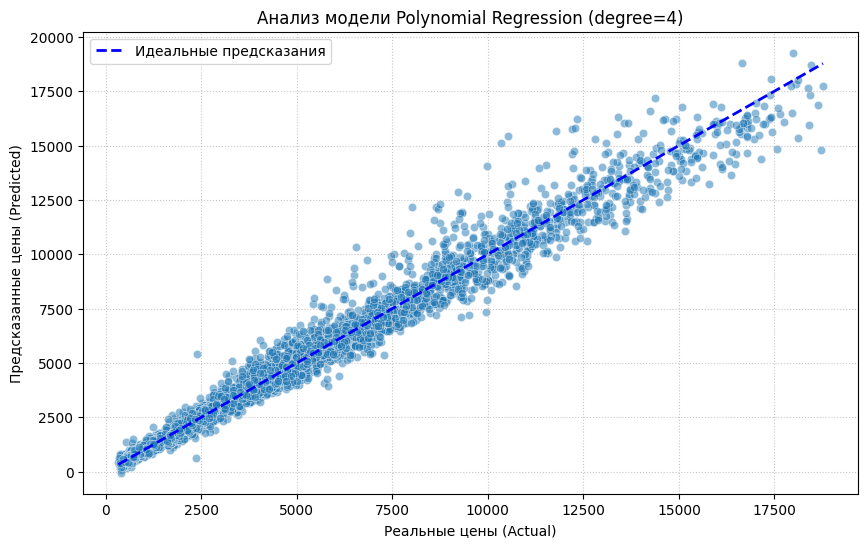

In [12]:
evaluate_model_visual('Polynomial Regression (degree=4)', y_pred, y_test)

На графике видно, что точки ложатся очень плотно к синей пунктирной линии. Это подтверждает, что модель 4-й степени отлично «подстроилась» под данные и уловила нелинейный характер зависимости цены от параметров алмазов.

- **Точность.** За счет использования полинома удалось убрать систематические ошибки, которые были у обычной линейной регрессии (особенно на краях графика — в области очень дешевых и очень дорогих камней).
- **Ошибки на дорогих объектах.** В правой части графика (при цене выше 15 000) заметно небольшое «облако» — разброс предсказаний увеличивается. Это логично, так как крупные алмазы оцениваются сложнее, там больше влияют индивидуальные характеристики (чистота, огранка), которые труднее предсказать идеально.

### Собственные метрики

In [14]:
def MAE(y_test, y_pred):
    return np.mean(np.abs(y_test - y_pred))

def MSE(y_test, y_pred):
    return np.mean(np.power((y_test-y_pred), 2))

def RMSE(y_test, y_pred):
    return np.power(np.mean(np.power((y_test-y_pred), 2)), 0.5)

def MAPE(y_test, y_pred):
    y_test = y_test.replace(0, 1e-10)
    return np.power(np.mean(np.abs( np.divide((y_test - y_pred), y_test) )), 0.5)

def R_2(y_test, y_pred):
    mse = np.mean(np.power((y_test-y_pred), 2))
    y_train_mean = np.mean(y_train)
    denominator = np.mean(np.power((y_train - y_train_mean), 2))
    return 1 - np.divide(mse, denominator)

print(f"MAE = {round(MAE(y_test, y_pred), 4)}")
print(f"MSE = {round(MSE(y_test, y_pred), 4)}")
print(f"RMSE = {round(RMSE(y_test, y_pred), 4)}")
print(f"MAPE = {round(MAPE(y_test, y_pred), 4)}")
print(f"R2 = {round(R_2(y_test, y_pred), 4)}")

results_df

MAE = 287.267
MSE = 249456.1619
RMSE = 499.4559
MAPE = 0.307
R2 = 0.9807


,Model,MAE,MSE,RMSE,MAPE,R2
0,Polynomial Regression,287.267,249456.1619,499.4559,0.307,0.9801


При сравнении ручного расчета R^2 и библиотечной функции `r2_score` выявлено незначительное расхождение в значениях (0.9807 против 0.9801). Данная погрешность (менее 0.07%) является допустимой и объясняется различиями в реализации алгоритмов , а также особенностями округления чисел с плавающей запятой при операциях с большими суммами квадратов.

Остальные значения метрик оказались одинаковыми.